#📊 Structural and Funding Context Analysis

This notebook examines structural and funding conditions that shape refugee
education access, including refugee population distribution and official
development assistance (ODA) patterns. While these datasets do not directly
measure higher education access, they help explain the broader context that may
affect future educational pathways.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
region_df = pd.read_csv("school_age_refugee_population_by_region.csv")
income_df = pd.read_csv("school_age_refugee_population_by_income.csv")
oda_df = pd.read_csv("oda_by_type_of_aid.csv")

In [ ]:

for df in [region_df, income_df, oda_df]:
    df.columns = df.columns.str.strip()

print("region_df columns:", region_df.columns.tolist())
display(region_df.head(3))

print("\nincome_df columns:", income_df.columns.tolist())
display(income_df.head(3))

print("\noda_df columns:", oda_df.columns.tolist())
display(oda_df.head(3))

region_df columns: ['region', 'year', 'school_age_refugee_population']


,region,year,school_age_refugee_population
0,EAP,2001,116921.88
1,ECA,2001,807001.88
2,LAC,2001,15024.64



income_df columns: ['income_group', 'year', 'school_age_refugee_population']


,income_group,year,school_age_refugee_population
0,Lower middle income,2001,1775753.88
1,Upper middle income,2001,247790.92
2,High income,2001,1049179.60



oda_df columns: ['type_of_aid', 'million_usd', 'proportion']


,type_of_aid,million_usd,proportion
0,Total Education,2629.903406,1.000000
1,Dev. Education,2292.815884,0.871825
2,HM. Education,323.419866,0.122978


In [ ]:
def pick_col(df, candidates_exact=None, candidates_contains=None, required=True):
    """
    Try to find a column by exact match first, then by substring match (case-insensitive).
    """
    cols = list(df.columns)
    lower_map = {c.lower(): c for c in cols}

   
    if candidates_exact:
        for cand in candidates_exact:
            if cand.lower() in lower_map:
                return lower_map[cand.lower()]

 
    if candidates_contains:
        for c in cols:
            cl = c.lower()
            if any(sub.lower() in cl for sub in candidates_contains):
                return c

    if required:
        raise ValueError(f"Could not find column. Available columns: {cols}")
    return None


def to_numeric_safe(df, col):
    df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def latest_year_subset(df, year_col):
    df = df.copy()
    df = to_numeric_safe(df, year_col)
    df = df.dropna(subset=[year_col])
    df[year_col] = df[year_col].astype(int)
    latest_year = int(df[year_col].max())
    return df[df[year_col] == latest_year].copy(), latest_year

## School-Age Refugee Population by Region

,region,school_age_refugee_population
1,ECA,3978533.20
5,SSA,3245768.08
3,MENA,1932851.32
2,LAC,1646605.48
4,SA,939331.00
0,EAP,365415.24


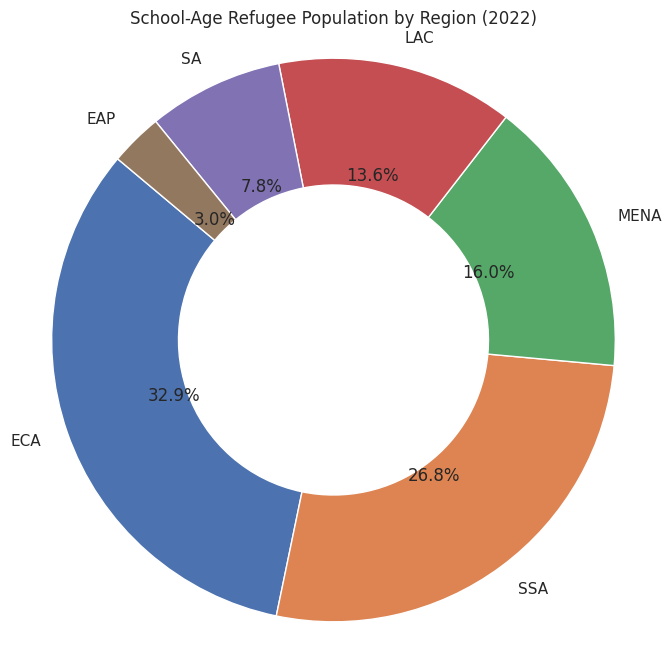

In [7]:

region_plot = region_df.copy()

region_plot = region_plot.dropna(subset=[region_name_col, region_value_col, region_year_col]).copy()


region_plot[region_name_col] = region_plot[region_name_col].astype(str).str.strip()
region_plot[region_value_col] = pd.to_numeric(region_plot[region_value_col], errors="coerce")
region_plot[region_year_col] = pd.to_numeric(region_plot[region_year_col], errors="coerce")

region_plot = region_plot[
    ~region_plot[region_name_col].str.lower().isin(["nan", "none", ""])
].copy()

region_plot = region_plot[
    region_plot[region_name_col].str.lower() != "world"
].copy()

if "geo_group_type" in region_plot.columns:
    region_plot["geo_group_type"] = region_plot["geo_group_type"].astype(str).str.strip().str.upper()
    if "SDG" in set(region_plot["geo_group_type"].dropna().unique()):
        region_plot = region_plot[region_plot["geo_group_type"] == "SDG"].copy()

region_plot = region_plot.dropna(subset=[region_year_col, region_value_col])
region_plot[region_year_col] = region_plot[region_year_col].astype(int)
latest_region_year = int(region_plot[region_year_col].max())

plot_region = region_plot[region_plot[region_year_col] == latest_region_year].copy()

region_agg = (
    plot_region.groupby(region_name_col, as_index=False)[region_value_col]
    .sum()
    .sort_values(region_value_col, ascending=False)
)

display(region_agg)

plt.figure(figsize=(8, 8))
plt.pie(
    region_agg[region_value_col],
    labels=region_agg[region_name_col],
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"width": 0.45}
)
plt.title(f"School-Age Refugee Population by Region ({latest_region_year})")
plt.axis("equal")
plt.show()

**Insight:**  
This chart shows how school-age refugee populations are distributed across regions.
A large share is concentrated in a few regions, which may increase pressure on
local education systems and contribute to long-term access barriers.

## School-Age Refugee Population by Host Country Income Group

,year,income_group,school_age_refugee_population
0,2001,High income,1049179.60
1,2001,Lower middle income,1775753.88
2,2001,Misc,11.00
3,2001,Upper middle income,247790.92
4,2002,High income,1101622.84


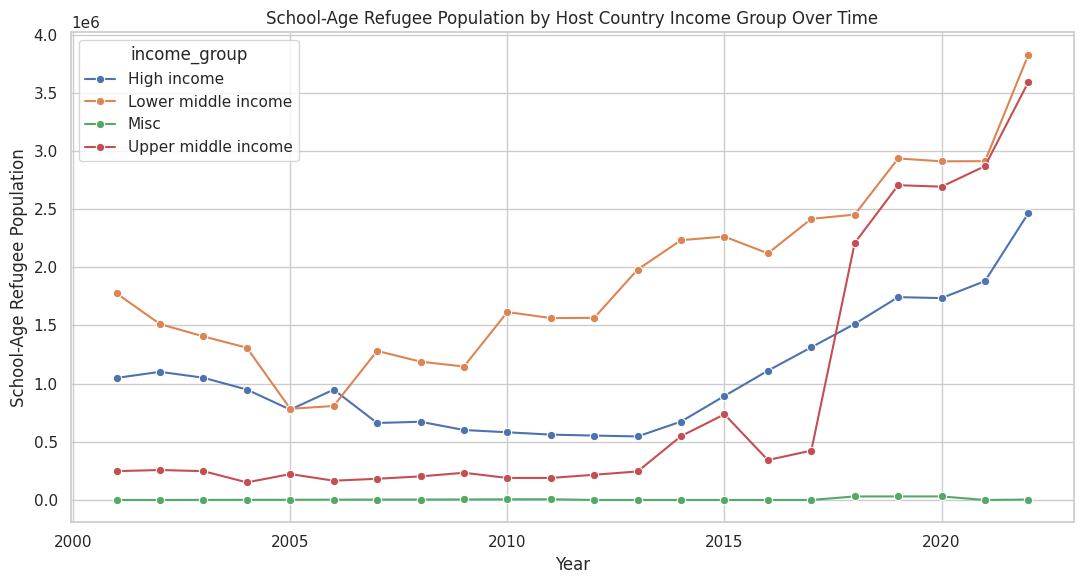

In [ ]:

income_year_col = pick_col(income_df, candidates_exact=["year"], candidates_contains=["year"])
income_name_col = pick_col(
    income_df,
    candidates_exact=["geo_group_name", "income_group"],
    candidates_contains=["income", "geo_group_name"]
)
income_type_col = pick_col(income_df, candidates_exact=["geo_group_type"], candidates_contains=["geo_group_type"], required=False)
income_value_col = pick_col(
    income_df,
    candidates_exact=["school_age_refugee_population", "value", "population"],
    candidates_contains=["population", "school_age", "value"]
)


income_line = income_df.copy()
income_line = income_line.dropna(subset=[income_year_col, income_name_col, income_value_col]).copy()

income_line[income_name_col] = income_line[income_name_col].astype(str).str.strip()
income_line[income_year_col] = pd.to_numeric(income_line[income_year_col], errors="coerce")
income_line[income_value_col] = pd.to_numeric(income_line[income_value_col], errors="coerce")

income_line = income_line.dropna(subset=[income_year_col, income_value_col]).copy()
income_line[income_year_col] = income_line[income_year_col].astype(int)


income_line = income_line[
    ~income_line[income_name_col].str.lower().isin(["nan", "none", "", "world"])
].copy()

if income_type_col and income_type_col in income_line.columns:
    income_line[income_type_col] = income_line[income_type_col].astype(str).str.strip().str.upper()
    if "WB" in set(income_line[income_type_col].dropna().unique()):
        income_line = income_line[income_line[income_type_col] == "WB"].copy()

income_trend = (
    income_line.groupby([income_year_col, income_name_col], as_index=False)[income_value_col]
    .sum()
)

display(income_trend.head())

plt.figure(figsize=(11, 6))
sns.lineplot(
    data=income_trend,
    x=income_year_col,
    y=income_value_col,
    hue=income_name_col,
    marker="o"
)

plt.title("School-Age Refugee Population by Host Country Income Group Over Time")
plt.xlabel("Year")
plt.ylabel("School-Age Refugee Population")
plt.tight_layout()
plt.show()

**Insight:**  
This chart tracks how school-age refugee populations evolve across host-country
income groups. Persistent concentration in lower-income settings may reflect
long-term capacity and funding challenges for education systems.

# Composition of Education-Related ODA by Aid Type

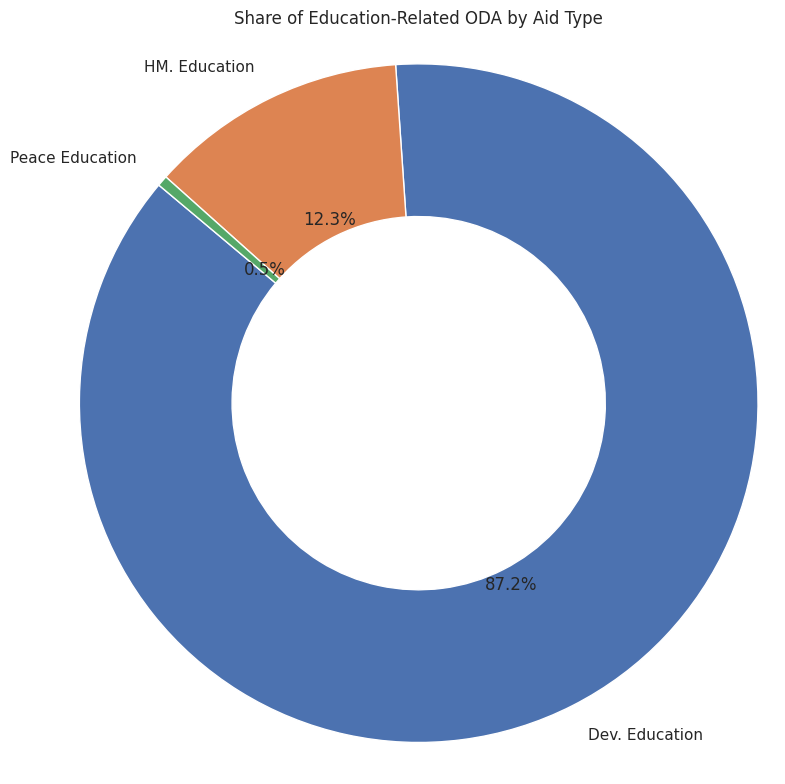

In [ ]:

oda_donut = oda_components.copy()

plt.figure(figsize=(8, 8))
plt.pie(
    oda_donut["million_usd"],   
    labels=oda_donut["type_of_aid"],
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"width": 0.45}
)
plt.title("Share of Education-Related ODA by Aid Type")
plt.axis("equal")
plt.tight_layout()
plt.show()

**Insight:**  
Most education-related ODA in this dataset is concentrated in development
education funding, while humanitarian and peace education represent smaller
shares. This may suggest stronger support for long-term education programming
than emergency or peace-focused education components in this snapshot.

### Key Terms (Quick Definitions)

- **ODA (Official Development Assistance):** Government aid used to support development and welfare.

- **Proportion:** The share of one category compared to the total (often shown as a percentage).

- **Snapshot dataset:** A dataset that shows one summary breakdown, not changes over time.

- **Proxy indicator:** An indirect measure used to help understand a bigger issue when direct data is not available.

- **Dev. Education (Development Education):** Long-term education support (for example systems, schools, planning, and programs).

- **HM. Education (Humanitarian Education):** Education support in emergencies and crisis situations (conflict, displacement, disasters).

- **Peace Education:** Education programs that promote peace, conflict prevention, and social cohesion.

- **Other Education:** Education-related aid that does not fit the main categories.

### Region Abbreviations

- **SSA:** Sub-Saharan Africa  
- **MENA:** Middle East and North Africa  
- **LAC:** Latin America and the Caribbean  
- **SA:** South Asia  
- **EAP:** East Asia and Pacific  
- **ECA:** Europe and Central Asia